# `rag-stress` — Evaluation & Analysis

This notebook evaluates the four inference outputs produced by `05_run_llm_inference_T4_vllm.ipynb`.

It computes:

## Clean / Distractor / Position
- Exact Match (EM)
- Token F1
- Mean performance by condition
- Accuracy degradation relative to clean

## Counterfactual
- `GOLD_FOLLOW`
- `COUNTERFACTUAL_FOLLOW`
- `OTHER`
- Counterfactual Follow Rate (CFR)
- Gold Follow Rate (GFR)

It also creates the main plots for the project.


In [2]:
from pathlib import Path
import json
import re
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

# ---------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------
drive.mount("/content/drive")

# ---------------------------------------------------------
# Google Drive paths
# ---------------------------------------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

# Inference outputs generated by the inference notebook
RESULTS_DIR = DRIVE_ROOT / "outputs"

# Evaluation outputs generated by this notebook
EVAL_DIR = DRIVE_ROOT / "evaluation"

# Figures generated by this notebook
FIGURES_DIR = EVAL_DIR / "figures"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Input answer files
# ---------------------------------------------------------
CLEAN_FILE = RESULTS_DIR / "clean_answers.jsonl"
DISTRACTOR_FILE = RESULTS_DIR / "distractor_answers.jsonl"
POSITION_FILE = RESULTS_DIR / "position_answers.jsonl"
COUNTERFACTUAL_FILE = RESULTS_DIR / "counterfactual_answers.jsonl"

print("Google Drive root :", DRIVE_ROOT)
print("Reading answers   :", RESULTS_DIR)
print("Saving evaluation :", EVAL_DIR)
print("Saving figures    :", FIGURES_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive root : /content/drive/MyDrive/rag_stress
Reading answers   : /content/drive/MyDrive/rag_stress/outputs
Saving evaluation : /content/drive/MyDrive/rag_stress/evaluation
Saving figures    : /content/drive/MyDrive/rag_stress/evaluation/figures


## 1. Load results

In [3]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


files = {
    "clean": CLEAN_FILE,
    "distractor": DISTRACTOR_FILE,
    "position": POSITION_FILE,
    "counterfactual": COUNTERFACTUAL_FILE,
}

for name, path in files.items():
    print(
        f"{name:15s}",
        "FOUND" if path.exists() else "MISSING",
        "->",
        path
    )

missing = [
    str(path)
    for path in files.values()
    if not path.exists()
]

assert not missing, (
    "Missing inference result file(s):\n"
    + "\n".join(missing)
)

clean = load_jsonl(CLEAN_FILE)
distractor = load_jsonl(DISTRACTOR_FILE)
position = load_jsonl(POSITION_FILE)
counterfactual = load_jsonl(COUNTERFACTUAL_FILE)

print("\nRows:")
print("Clean:", len(clean))
print("Distractor:", len(distractor))
print("Position:", len(position))
print("Counterfactual:", len(counterfactual))

clean           FOUND -> /content/drive/MyDrive/rag_stress/outputs/clean_answers.jsonl
distractor      FOUND -> /content/drive/MyDrive/rag_stress/outputs/distractor_answers.jsonl
position        FOUND -> /content/drive/MyDrive/rag_stress/outputs/position_answers.jsonl
counterfactual  FOUND -> /content/drive/MyDrive/rag_stress/outputs/counterfactual_answers.jsonl

Rows:
Clean: 500
Distractor: 1500
Position: 1500
Counterfactual: 431


## 2. SQuAD-style answer normalization

In [5]:
def normalize_answer(text):
    """
    Standard QA normalization:
      1. lowercase
      2. remove punctuation
      3. remove articles a/an/the
      4. collapse whitespace
    """
    text = str(text).lower()

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text
    )

    text = " ".join(
        text.split()
    )

    return text

## 3. Exact Match

In [8]:
def exact_match(prediction, gold):
    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(gold)
    )


## 4. Token F1

In [9]:
def token_f1(prediction, gold):
    pred_tokens = normalize_answer(
        prediction
    ).split()

    gold_tokens = normalize_answer(
        gold
    ).split()

    # both empty
    if not pred_tokens and not gold_tokens:
        return 1.0

    # only one empty
    if not pred_tokens or not gold_tokens:
        return 0.0

    pred_counts = Counter(pred_tokens)
    gold_counts = Counter(gold_tokens)

    common = pred_counts & gold_counts
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = (
        num_same
        / len(pred_tokens)
    )

    recall = (
        num_same
        / len(gold_tokens)
    )

    return (
        2
        * precision
        * recall
        / (precision + recall)
    )


## 5. Add EM/F1 to clean, distractor, and position results


In [10]:
def evaluate_standard(records):
    evaluated = []

    for row in records:
        pred = row["model_answer"]
        gold = row["gold_answer"]

        new_row = dict(row)

        new_row["em"] = exact_match(
            pred,
            gold
        )

        new_row["f1"] = token_f1(
            pred,
            gold
        )

        evaluated.append(
            new_row
        )

    return evaluated


clean_eval = evaluate_standard(clean)
distractor_eval = evaluate_standard(distractor)
position_eval = evaluate_standard(position)

print("Evaluated.")


Evaluated.


## 6. Clean baseline performance

In [11]:
clean_em = np.mean(
    [r["em"] for r in clean_eval]
)

clean_f1 = np.mean(
    [r["f1"] for r in clean_eval]
)

print(
    f"Clean EM : {clean_em:.4f}"
)
print(
    f"Clean F1 : {clean_f1:.4f}"
)


Clean EM : 0.4920
Clean F1 : 0.6657


## 7. Distractor results by condition

In [12]:
def aggregate_by_condition(records):
    groups = defaultdict(list)

    for row in records:
        groups[
            row["condition"]
        ].append(row)

    summary = []

    for condition, rows_ in groups.items():
        summary.append({
            "condition": condition,
            "n": len(rows_),
            "em": np.mean(
                [r["em"] for r in rows_]
            ),
            "f1": np.mean(
                [r["f1"] for r in rows_]
            ),
        })

    return pd.DataFrame(summary)


distractor_summary = aggregate_by_condition(
    distractor_eval
)

order = ["D1", "D3", "D5"]

distractor_summary["condition"] = pd.Categorical(
    distractor_summary["condition"],
    categories=order,
    ordered=True
)

distractor_summary = (
    distractor_summary
    .sort_values("condition")
    .reset_index(drop=True)
)

distractor_summary["em_drop_vs_clean"] = (
    clean_em
    - distractor_summary["em"]
)

distractor_summary["f1_drop_vs_clean"] = (
    clean_f1
    - distractor_summary["f1"]
)

display(
    distractor_summary.round(4)
)


,condition,n,em,f1,em_drop_vs_clean,f1_drop_vs_clean
0,D1,500,0.462,0.6125,0.030,0.0532
1,D3,500,0.434,0.5929,0.058,0.0729
2,D5,500,0.430,0.5797,0.062,0.0861


## 8. Position results by condition

In [13]:
position_summary = aggregate_by_condition(
    position_eval
)

position_order = [
    "beginning",
    "middle",
    "end"
]

position_summary["condition"] = pd.Categorical(
    position_summary["condition"],
    categories=position_order,
    ordered=True
)

position_summary = (
    position_summary
    .sort_values("condition")
    .reset_index(drop=True)
)

position_summary["em_drop_vs_clean"] = (
    clean_em
    - position_summary["em"]
)

position_summary["f1_drop_vs_clean"] = (
    clean_f1
    - position_summary["f1"]
)

display(
    position_summary.round(4)
)


,condition,n,em,f1,em_drop_vs_clean,f1_drop_vs_clean
0,beginning,500,0.432,0.5910,0.060,0.0748
1,middle,500,0.420,0.5829,0.072,0.0828
2,end,500,0.444,0.6060,0.048,0.0598


## 9. Counterfactual classification

Each prediction is classified as:

- `COUNTERFACTUAL_FOLLOW`
- `GOLD_FOLLOW`
- `OTHER`

Priority rule:

1. exact match to counterfactual answer
2. exact match to gold answer
3. otherwise `OTHER`


In [14]:
def classify_counterfactual(row):
    pred = normalize_answer(
        row["model_answer"]
    )

    gold = normalize_answer(
        row["gold_answer"]
    )

    cf = normalize_answer(
        row["counterfactual_answer"]
    )

    if pred == cf:
        return "COUNTERFACTUAL_FOLLOW"

    if pred == gold:
        return "GOLD_FOLLOW"

    return "OTHER"


counterfactual_eval = []

for row in counterfactual:
    new_row = dict(row)

    new_row["cf_class"] = (
        classify_counterfactual(row)
    )

    counterfactual_eval.append(
        new_row
    )


## 10. Counterfactual metrics

In [15]:
cf_counts = Counter(
    r["cf_class"]
    for r in counterfactual_eval
)

cf_total = len(
    counterfactual_eval
)

cfr = (
    cf_counts["COUNTERFACTUAL_FOLLOW"]
    / cf_total
)

gfr = (
    cf_counts["GOLD_FOLLOW"]
    / cf_total
)

other_rate = (
    cf_counts["OTHER"]
    / cf_total
)

print("Counterfactual examples:", cf_total)
print()
print(
    "COUNTERFACTUAL_FOLLOW:",
    cf_counts["COUNTERFACTUAL_FOLLOW"],
    f"({cfr:.4f})"
)
print(
    "GOLD_FOLLOW:",
    cf_counts["GOLD_FOLLOW"],
    f"({gfr:.4f})"
)
print(
    "OTHER:",
    cf_counts["OTHER"],
    f"({other_rate:.4f})"
)

cf_summary = pd.DataFrame([
    {
        "behavior":
            "COUNTERFACTUAL_FOLLOW",
        "count":
            cf_counts[
                "COUNTERFACTUAL_FOLLOW"
            ],
        "rate": cfr,
    },
    {
        "behavior":
            "GOLD_FOLLOW",
        "count":
            cf_counts[
                "GOLD_FOLLOW"
            ],
        "rate": gfr,
    },
    {
        "behavior":
            "OTHER",
        "count":
            cf_counts["OTHER"],
        "rate": other_rate,
    },
])

display(
    cf_summary.round(4)
)


Counterfactual examples: 431

COUNTERFACTUAL_FOLLOW: 136 (0.3155)
GOLD_FOLLOW: 17 (0.0394)
OTHER: 278 (0.6450)


,behavior,count,rate
0,COUNTERFACTUAL_FOLLOW,136,0.3155
1,GOLD_FOLLOW,17,0.0394
2,OTHER,278,0.6450


## 11. Counterfactual behavior by type


In [16]:
cf_type_table = (
    pd.DataFrame(
        counterfactual_eval
    )
    .groupby(
        [
            "counterfactual_type",
            "cf_class"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for col in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER"
]:
    if col not in cf_type_table.columns:
        cf_type_table[col] = 0

cf_type_table["total"] = (
    cf_type_table[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER"
        ]
    ].sum(axis=1)
)

cf_type_table["CFR"] = (
    cf_type_table[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / cf_type_table["total"]
)

cf_type_table["GFR"] = (
    cf_type_table[
        "GOLD_FOLLOW"
    ]
    / cf_type_table["total"]
)

display(
    cf_type_table
    .sort_values(
        "total",
        ascending=False
    )
    .round(4)
)


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR
counterfactual_type,,,,,,
ENTITY,61,12,173,246,0.2480,0.0488
NUMERIC,41,0,44,85,0.4824,0.0000
PERSON,18,0,26,44,0.4091,0.0000
CITY,4,0,11,15,0.2667,0.0000
COUNTRY,2,5,4,11,0.1818,0.4545
LOCATION,3,0,8,11,0.2727,0.0000
FILM,1,0,4,5,0.2000,0.0000
COMPANY,1,0,3,4,0.2500,0.0000
BAND,2,0,1,3,0.6667,0.0000


## 12. Plot — Distractor robustness

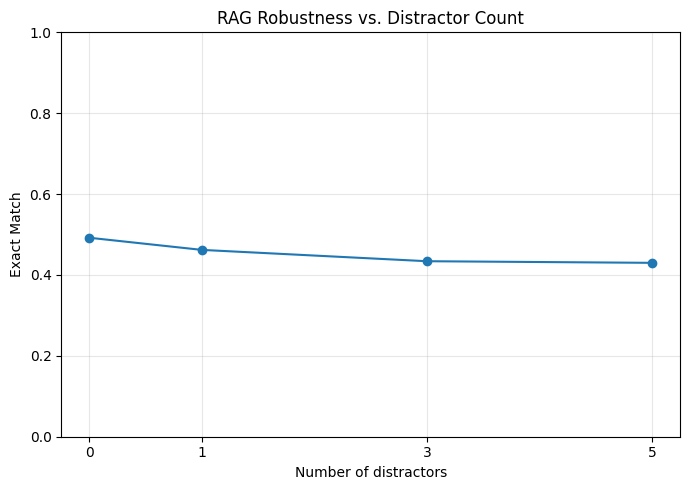

In [17]:
plt.figure(figsize=(7, 5))

x = [0, 1, 3, 5]

em_values = [
    clean_em,
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D1",
            "em"
        ].iloc[0]
    ),
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D3",
            "em"
        ].iloc[0]
    ),
    float(
        distractor_summary.loc[
            distractor_summary["condition"] == "D5",
            "em"
        ].iloc[0]
    ),
]

plt.plot(
    x,
    em_values,
    marker="o"
)

plt.xlabel(
    "Number of distractors"
)
plt.ylabel(
    "Exact Match"
)
plt.title(
    "RAG Robustness vs. Distractor Count"
)
plt.xticks(x)
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "distractor_robustness_em.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 13. Plot — Position bias

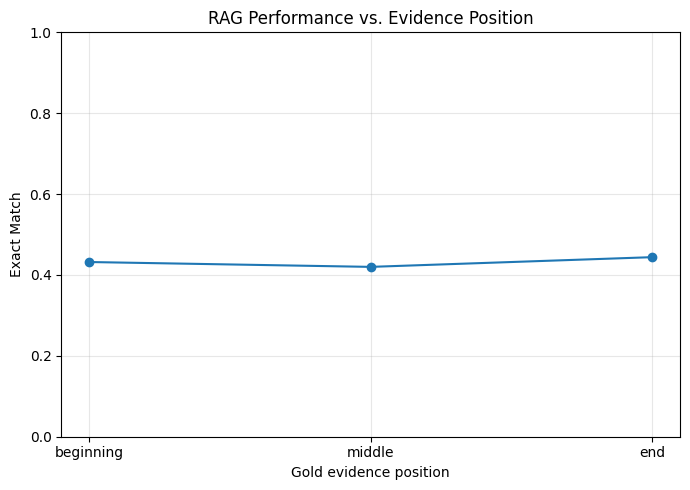

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(
    position_summary["condition"].astype(str),
    position_summary["em"],
    marker="o"
)

plt.xlabel(
    "Gold evidence position"
)
plt.ylabel(
    "Exact Match"
)
plt.title(
    "RAG Performance vs. Evidence Position"
)
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "position_bias_em.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 14. Plot — Counterfactual behavior

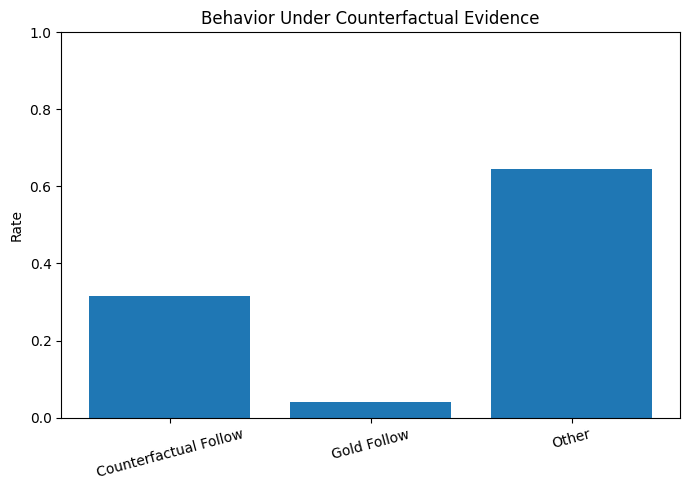

In [19]:
plt.figure(figsize=(7, 5))

labels = [
    "Counterfactual Follow",
    "Gold Follow",
    "Other"
]

values = [
    cfr,
    gfr,
    other_rate
]

plt.bar(
    labels,
    values
)

plt.ylabel("Rate")
plt.title(
    "Behavior Under Counterfactual Evidence"
)
plt.ylim(0, 1)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "counterfactual_behavior.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 15. Error analysis — clean failures


In [20]:
clean_failures = [
    r
    for r in clean_eval
    if r["em"] == 0
]

print(
    "Clean EM failures:",
    len(clean_failures)
)

for row in clean_failures[:10]:
    print("=" * 100)
    print("Q:", row["question"])
    print("Gold:", row["gold_answer"])
    print("Pred:", row["model_answer"])
    print("F1:", round(row["f1"], 3))


Clean EM failures: 254
Q: Paul DeBoy is known for an appearance in the Western action-adventure game developed by which company?
Gold: Rockstar San Diego
Pred: Rockstar Games
F1: 0.4
Q: What is the nickname of the peninsula that is home to the Calabrian Black Squirrel?
Gold: "lo Stivale" (the Boot)
Pred: lo Stivale
F1: 0.8
Q: Which player won more Grand Slam titles, Kevin Ullyett or Billie Jean King?
Gold: Billie Jean King
Pred: Billie Jean King won more Grand Slam titles than Kevin Ullyett.
F1: 0.429
Q: Who was a more acclaimed guitarist Stephen Christian or Joe Gooch?
Gold: and lead guitarist
Pred: INSUFFICIENT_EVIDENCE
F1: 0.0
Q:  Who was born earlier, Simone Bolelli or Caroline Wozniacki?
Gold: Simone Bolelli
Pred: Simone Bolelli was born earlier than Caroline Wozniacki.
F1: 0.4
Q: Which director had the longest career, Alain Resnais or Scott Sidney?
Gold: Scott Sidney
Pred: Alain Resnais had the longest career.
F1: 0.0
Q: Which film was released more recently, Make Mine Music or O

## 16. Error analysis — D5 failures


In [21]:
d5_failures = [
    r
    for r in distractor_eval
    if r["condition"] == "D5"
    and r["em"] == 0
]

print(
    "D5 EM failures:",
    len(d5_failures)
)

for row in d5_failures[:10]:
    print("=" * 100)
    print("Q:", row["question"])
    print("Gold:", row["gold_answer"])
    print("Pred:", row["model_answer"])
    print("F1:", round(row["f1"], 3))


D5 EM failures: 285
Q: Paul DeBoy is known for an appearance in the Western action-adventure game developed by which company?
Gold: Rockstar San Diego
Pred: Rockstar Games
F1: 0.4
Q: Which TV series directed and written by the same person as "Buffy the Vampire Slayer" starred Tahmoh Penikett?
Gold: Dollhouse
Pred: INSUFFICIENT_EVIDENCE
F1: 0.0
Q: What is the nickname of the peninsula that is home to the Calabrian Black Squirrel?
Gold: "lo Stivale" (the Boot)
Pred: lo Stivale
F1: 0.8
Q: Which player won more Grand Slam titles, Kevin Ullyett or Billie Jean King?
Gold: Billie Jean King
Pred: Billie Jean King won more Grand Slam titles than Kevin Ullyett.
F1: 0.429
Q: Who was a more acclaimed guitarist Stephen Christian or Joe Gooch?
Gold: and lead guitarist
Pred: INSUFFICIENT_EVIDENCE
F1: 0.0
Q: What is the birth name of the disc jockey that notably used Mark Wirtz's song "A Touch of Velvet, A Sting of Brass" on their Radio Caroline show?
Gold: David Patrick Griffin
Pred: Dave Lee Travis


## 17. Error analysis — counterfactual OTHER cases


In [22]:
cf_other = [
    r
    for r in counterfactual_eval
    if r["cf_class"] == "OTHER"
]

print(
    "Counterfactual OTHER cases:",
    len(cf_other)
)

for row in cf_other[:10]:
    print("=" * 100)
    print("Q:", row["question"])
    print("Gold:", row["gold_answer"])
    print(
        "Counterfactual:",
        row["counterfactual_answer"]
    )
    print("Pred:", row["model_answer"])


Counterfactual OTHER cases: 278
Q: Paul DeBoy is known for an appearance in the Western action-adventure game developed by which company?
Gold: Rockstar San Diego
Counterfactual: Restoration Hardware
Pred: Rockstar Games
Q: Which TV series directed and written by the same person as "Buffy the Vampire Slayer" starred Tahmoh Penikett?
Gold: Dollhouse
Counterfactual: Buffy the Vampire Slayer
Pred: Continuum
Q: What is the nickname of the peninsula that is home to the Calabrian Black Squirrel?
Gold: "lo Stivale" (the Boot)
Counterfactual: The Tales of Hoffmann
Pred: INSUFFICIENT_EVIDENCE
Q: What aviator participated to the Transatlantic flight organized by the "heir apparent" to Italian dictator Benito Mussolini?
Gold: Antonio Lippi
Counterfactual: heir apparent
Pred: Italo Balbo
Q: Who was a more acclaimed guitarist Stephen Christian or Joe Gooch?
Gold: and lead guitarist
Counterfactual: Joe Gooch
Pred: INSUFFICIENT_EVIDENCE
Q: What is the birth name of the disc jockey that notably used M

## 18. Save evaluated JSONLs


In [23]:
def write_jsonl(records, path):
    with path.open(
        "w",
        encoding="utf-8"
    ) as f:
        for row in records:
            f.write(
                json.dumps(
                    row,
                    ensure_ascii=False
                )
                + "\n"
            )


write_jsonl(
    clean_eval,
    EVAL_DIR / "clean_evaluated.jsonl"
)

write_jsonl(
    distractor_eval,
    EVAL_DIR / "distractor_evaluated.jsonl"
)

write_jsonl(
    position_eval,
    EVAL_DIR / "position_evaluated.jsonl"
)

write_jsonl(
    counterfactual_eval,
    EVAL_DIR / "counterfactual_evaluated.jsonl"
)

print("Saved evaluated JSONL files to:")
print(EVAL_DIR)


Saved evaluated JSONL files to:
/content/drive/MyDrive/rag_stress/evaluation


## 19. Save summary CSVs


In [24]:
distractor_summary.to_csv(
    EVAL_DIR
    / "distractor_summary.csv",
    index=False
)

position_summary.to_csv(
    EVAL_DIR
    / "position_summary.csv",
    index=False
)

cf_summary.to_csv(
    EVAL_DIR
    / "counterfactual_summary.csv",
    index=False
)

cf_type_table.to_csv(
    EVAL_DIR
    / "counterfactual_by_type.csv"
)

print("Saved CSV summaries to:", EVAL_DIR)


Saved CSV summaries to: /content/drive/MyDrive/rag_stress/evaluation


## 20. Save overall project summary


In [25]:
summary = {
    "clean": {
        "n": len(clean_eval),
        "em": float(clean_em),
        "f1": float(clean_f1),
    },

    "distractor": {
        row["condition"]: {
            "n": int(row["n"]),
            "em": float(row["em"]),
            "f1": float(row["f1"]),
            "em_drop_vs_clean":
                float(
                    row[
                        "em_drop_vs_clean"
                    ]
                ),
            "f1_drop_vs_clean":
                float(
                    row[
                        "f1_drop_vs_clean"
                    ]
                ),
        }
        for _, row
        in distractor_summary.iterrows()
    },

    "position": {
        row["condition"]: {
            "n": int(row["n"]),
            "em": float(row["em"]),
            "f1": float(row["f1"]),
            "em_drop_vs_clean":
                float(
                    row[
                        "em_drop_vs_clean"
                    ]
                ),
            "f1_drop_vs_clean":
                float(
                    row[
                        "f1_drop_vs_clean"
                    ]
                ),
        }
        for _, row
        in position_summary.iterrows()
    },

    "counterfactual": {
        "n": cf_total,
        "counterfactual_follow":
            int(
                cf_counts[
                    "COUNTERFACTUAL_FOLLOW"
                ]
            ),
        "gold_follow":
            int(
                cf_counts[
                    "GOLD_FOLLOW"
                ]
            ),
        "other":
            int(
                cf_counts[
                    "OTHER"
                ]
            ),
        "CFR": float(cfr),
        "GFR": float(gfr),
        "other_rate":
            float(other_rate),
    }
}

SUMMARY_FILE = EVAL_DIR / "rag_stress_summary.json"

with SUMMARY_FILE.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )

print(
    json.dumps(
        summary,
        indent=2
    )
)


{
  "clean": {
    "n": 500,
    "em": 0.492,
    "f1": 0.6657314040333168
  },
  "distractor": {
    "D1": {
      "n": 500,
      "em": 0.462,
      "f1": 0.6124935816195191,
      "em_drop_vs_clean": 0.02999999999999997,
      "f1_drop_vs_clean": 0.05323782241379771
    },
    "D3": {
      "n": 500,
      "em": 0.434,
      "f1": 0.5928579268845401,
      "em_drop_vs_clean": 0.057999999999999996,
      "f1_drop_vs_clean": 0.07287347714877668
    },
    "D5": {
      "n": 500,
      "em": 0.43,
      "f1": 0.5796562977770947,
      "em_drop_vs_clean": 0.062,
      "f1_drop_vs_clean": 0.08607510625622206
    }
  },
  "position": {
    "beginning": {
      "n": 500,
      "em": 0.432,
      "f1": 0.5909781400268859,
      "em_drop_vs_clean": 0.06,
      "f1_drop_vs_clean": 0.0747532640064309
    },
    "middle": {
      "n": 500,
      "em": 0.42,
      "f1": 0.5829188425777818,
      "em_drop_vs_clean": 0.07200000000000001,
      "f1_drop_vs_clean": 0.08281256145553495
    },
    "en

## Google Drive output locations

In [26]:
print("Evaluation outputs saved under:")
print(EVAL_DIR)

print("\nExpected files:")
for p in [
    EVAL_DIR / "clean_evaluated.jsonl",
    EVAL_DIR / "distractor_evaluated.jsonl",
    EVAL_DIR / "position_evaluated.jsonl",
    EVAL_DIR / "counterfactual_evaluated.jsonl",
    EVAL_DIR / "distractor_summary.csv",
    EVAL_DIR / "position_summary.csv",
    EVAL_DIR / "counterfactual_summary.csv",
    EVAL_DIR / "counterfactual_by_type.csv",
    EVAL_DIR / "rag_stress_summary.json",
    FIGURES_DIR / "distractor_robustness_em.png",
    FIGURES_DIR / "position_bias_em.png",
    FIGURES_DIR / "counterfactual_behavior.png",
]:
    print("-", p)


Evaluation outputs saved under:
/content/drive/MyDrive/rag_stress/evaluation

Expected files:
- /content/drive/MyDrive/rag_stress/evaluation/clean_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/evaluation/distractor_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/evaluation/position_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/evaluation/counterfactual_evaluated.jsonl
- /content/drive/MyDrive/rag_stress/evaluation/distractor_summary.csv
- /content/drive/MyDrive/rag_stress/evaluation/position_summary.csv
- /content/drive/MyDrive/rag_stress/evaluation/counterfactual_summary.csv
- /content/drive/MyDrive/rag_stress/evaluation/counterfactual_by_type.csv
- /content/drive/MyDrive/rag_stress/evaluation/rag_stress_summary.json
- /content/drive/MyDrive/rag_stress/evaluation/figures/distractor_robustness_em.png
- /content/drive/MyDrive/rag_stress/evaluation/figures/position_bias_em.png
- /content/drive/MyDrive/rag_stress/evaluation/figures/counterfactual_behavior.png
